<a href="https://colab.research.google.com/github/nourelfeky/California-Housing-KMeans/blob/main/California_Housing_Kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [4]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("Dataset loaded successfully!")
df.head(10)

Dataset loaded successfully!


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [5]:
print("Shape of dataset:", df.shape)

Shape of dataset: (20640, 9)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [7]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [8]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [9]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New shape:", df.shape)

Number of duplicate rows: 0


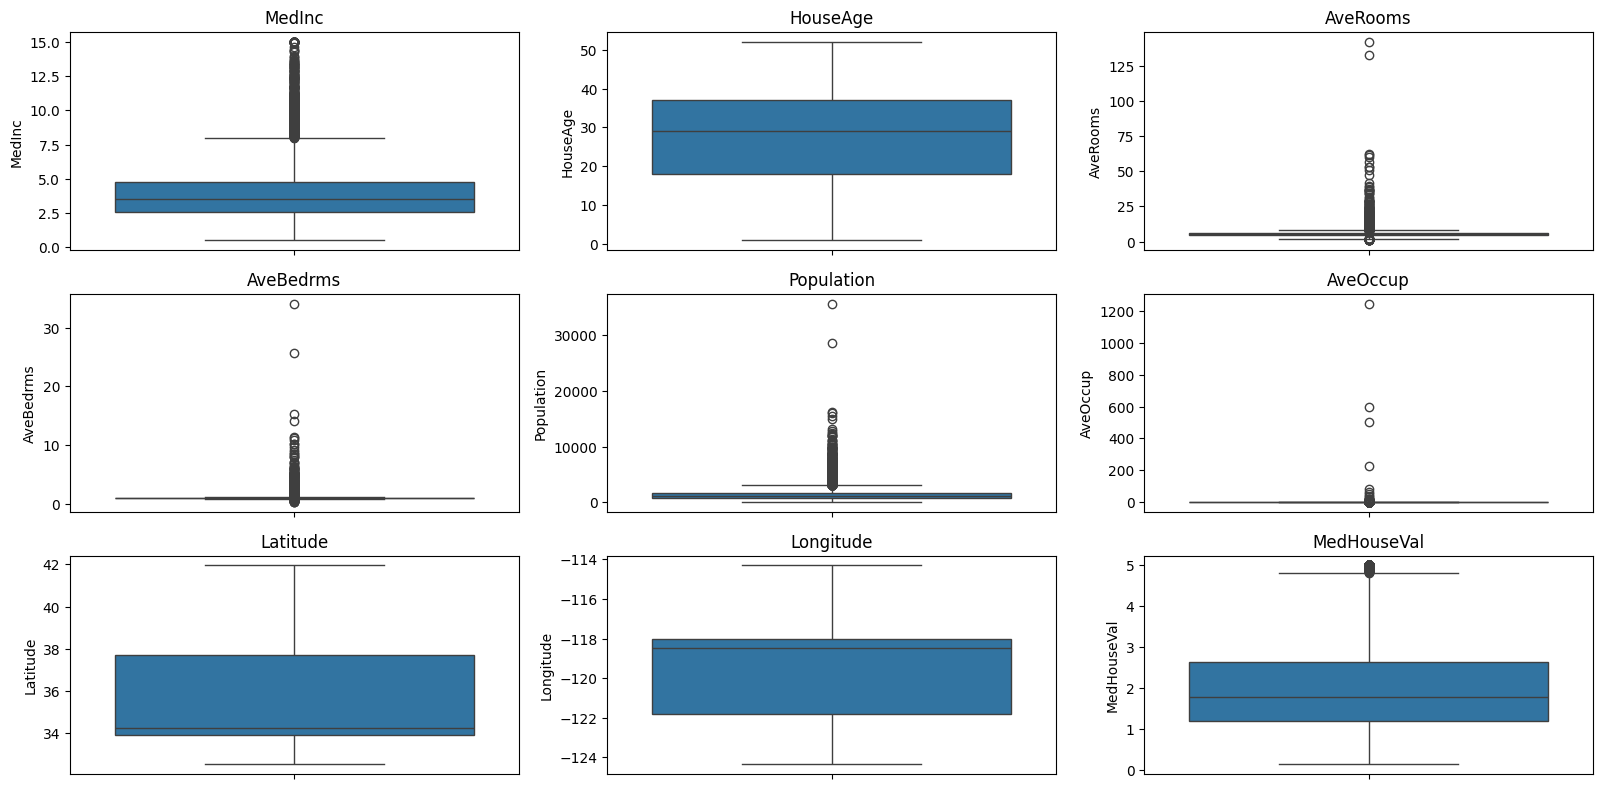

In [10]:
plt.figure(figsize=(16, 8))
for i, col in enumerate(df.columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [11]:
def cap_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[column] = np.clip(data[column], lower_bound, upper_bound)
    return data

df_clean = df.copy()
for col in df_clean.columns:
    df_clean = cap_outliers_iqr(df_clean, col)

print("Outliers capped using IQR method.")
df_clean.describe()

Outliers capped using IQR method.


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.801010,28.639486,5.304740,1.057958,1336.959012,2.899647,35.631861,-119.569704,2.059812
std,1.657658,12.585558,1.246177,0.080448,765.550830,0.691142,2.135952,2.003532,1.132174
min,0.499900,1.000000,2.023219,0.865909,3.000000,1.150961,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,8.013025,52.000000,8.469878,1.239697,3132.000000,4.561041,41.950000,-114.310000,4.824125


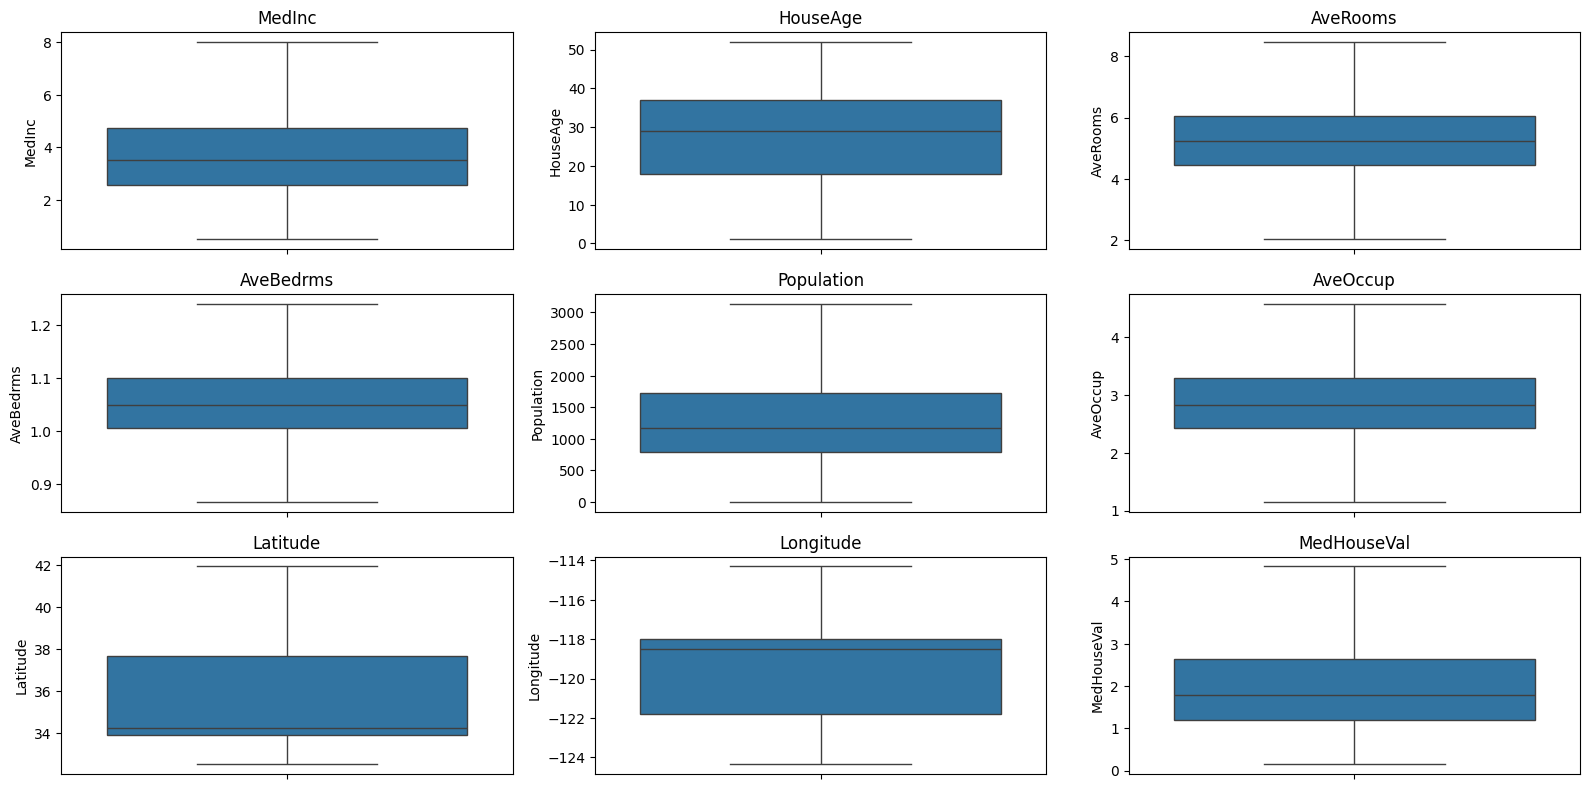

In [12]:
plt.figure(figsize=(16, 8))
for i, col in enumerate(df_clean.columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df_clean[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [13]:
features = df_clean.drop(columns=["MedHouseVal"])
print("Features used for clustering:")
print(list(features.columns))
features.head()

Features used for clustering:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.013025,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.013025,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.257400,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.643100,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.846200,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [14]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

scaled_df = pd.DataFrame(scaled_features, columns=features.columns)
scaled_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.541006,0.982143,1.347665,-0.424488,-1.325821,-0.497871,1.052548,-1.327835
1,2.541006,-0.607019,0.749027,-1.070004,1.389936,-1.142781,1.043185,-1.322844
2,2.085156,1.856182,2.394098,0.192534,-1.098528,-0.140910,1.038503,-1.332827
3,1.111288,1.856182,0.411358,0.187723,-1.017539,-0.508882,1.038503,-1.337818
4,0.027262,1.856182,0.784108,0.287439,-1.008395,-1.039145,1.038503,-1.337818


In [15]:
sample_size = min(5000, scaled_df.shape[0])
sample_df = scaled_df.sample(n=sample_size, random_state=42)

k_range = range(2, 11)
inertia_values = []
silhouette_scores = []

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(sample_df)

    inertia_values.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(sample_df, labels_temp))

print("Inertia values:", [round(v, 2) for v in inertia_values])
print("Silhouette scores:", [round(v, 3) for v in silhouette_scores])

Inertia values: [30973.17, 27093.71, 24504.88, 22582.47, 20903.2, 19366.77, 18329.76, 17451.63, 16725.28]
Silhouette scores: [np.float64(0.228), np.float64(0.198), np.float64(0.186), np.float64(0.188), np.float64(0.188), np.float64(0.184), np.float64(0.183), np.float64(0.18), np.float64(0.177)]


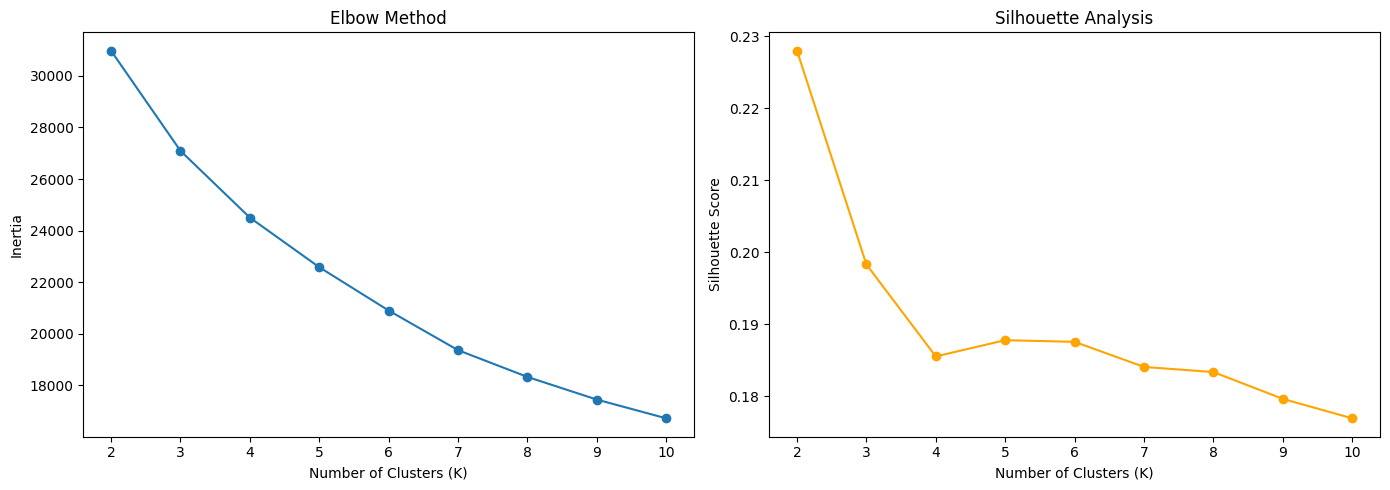

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method plot
axes[0].plot(list(k_range), inertia_values, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")

# Silhouette Score plot
axes[1].plot(list(k_range), silhouette_scores, marker="o", color="orange")
axes[1].set_title("Silhouette Analysis")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [17]:
optimal_k = 4
print(f"Selected K = {optimal_k}")

Selected K = 4


In [18]:
kmeans_final = KMeans(n_clusters=optimal_k, init="k-means++", random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(scaled_df)

df_clean["Cluster"] = cluster_labels

print("Number of points in each cluster:")
df_clean["Cluster"].value_counts().sort_index()

Number of points in each cluster:


,count
Cluster,
0,7093
1,5682
2,3894
3,3971


In [19]:
cluster_summary = df_clean.groupby("Cluster").mean(numeric_only=True)
cluster_summary

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
Cluster,,,,,,,,,
0,3.391824,30.528267,5.294885,1.065821,1139.303539,2.646484,38.081349,-121.797581,1.835327
1,3.505393,30.787751,4.928490,1.061908,1117.362196,2.509454,33.905815,-117.978002,2.159957
2,6.133812,20.452491,6.857938,1.046090,1539.773498,2.994321,35.015755,-119.084838,2.983332
3,2.667319,30.220096,4.337628,1.049898,1805.344749,3.817323,34.330501,-118.343261,1.411880


In [20]:
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
pca_df["Cluster"] = cluster_labels

explained_var = pca.explained_variance_ratio_
print(f"Explained variance by PC1: {explained_var[0]:.2%}")
print(f"Explained variance by PC2: {explained_var[1]:.2%}")
print(f"Total explained variance: {explained_var.sum():.2%}")

Explained variance by PC1: 26.03%
Explained variance by PC2: 21.90%
Total explained variance: 47.93%


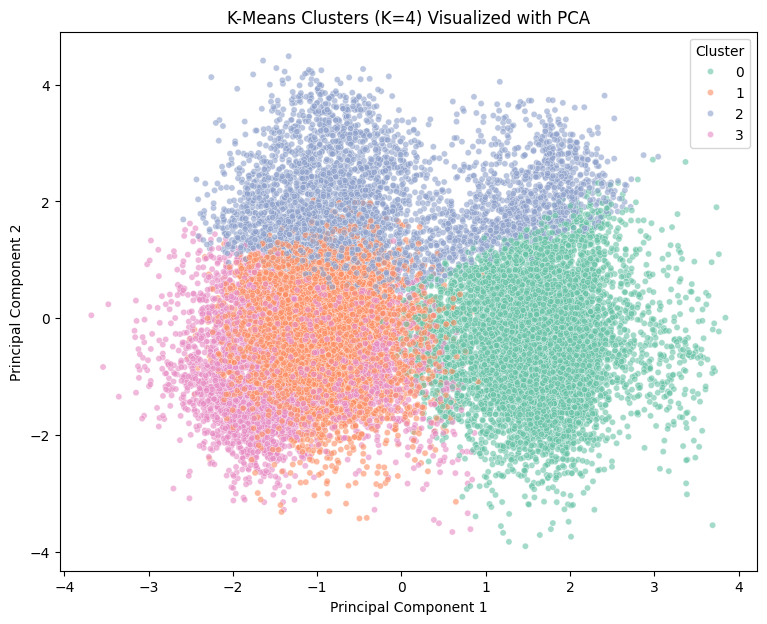

In [21]:
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    alpha=0.6,
    s=20
)
plt.title(f"K-Means Clusters (K={optimal_k}) Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()